In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
from pycbc.waveform import get_td_waveform, taper_timeseries
from scipy.special import expit

import numpy as np
import matplotlib.pyplot as plt

from scipy.fft import rfft, irfft, rfftfreq

In [3]:
LALSIMULATION_RINGING_EXTENT = 19
def Planck_window_LAL(data, taper_method='LAL_SIM_INSPIRAL_TAPER_STARTEND', num_extrema_start=32, num_extrema_end=32):
    start=0
    end=0
    n=0
    length = len(data)

    # Search for start and end of signal
    flag = 0
    i = 0
    while(flag == 0 and i < length):
        if (data[i] != 0.):
            start = i
            flag = 1
        i+=1
    if (flag == 0):
        raise ValueError("No signal found in the vector. Cannot taper.\n")

    flag = 0
    i = length - 1
    while( flag == 0 ):
        if( data[i] != 0. ):
                end = i
                flag = 1
        i-=1

    # Check we have more than 2 data points 
    if( (end - start) <= 1 ):
        raise RuntimeError( "Data less than 3 points, cannot taper!\n" )

    # Calculate middle point in case of short waveform
    mid = int((start+end)/2)

    window = np.ones(length)
    # If requested search for num_extrema_start-th peak from start and taper
    if( taper_method != "LAL_SIM_INSPIRAL_TAPER_END" ):
        flag = 0
        i = start+1
        while ( flag < num_extrema_start and i != mid ):
            if( abs(data[i]) >= abs(data[i-1]) and
                abs(data[i]) >= abs(data[i+1]) ):
            
                if( abs(data[i]) == abs(data[i+1]) ):
                    i+=1
                # only count local extrema more than 19 samples in
                if ( i-start > LALSIMULATION_RINGING_EXTENT ):
                    flag+=1
                n = i - start
            i+=1

        # Have we reached the middle without finding `num_extrema_start` peaks?
        if( flag < num_extrema_start ):
            n = mid - start
            print(f"""WARNING: Reached the middle of waveform without finding {num_extrema_start} extrema. Tapering only till the middle from the beginning.""")

        # Taper to that point
        realN = n
        window[:start+1] = 0.0
        realI = np.arange(1, n - 1)
        z = (realN - 1.0)/realI + (realN - 1.0)/(realI - (realN - 1.0))
        window[start+1: start+n-1] = 1.0/(expit(z) + 1.0)

    # If requested search for num_extrema_end-th peak from end
    if( taper_method == "LAL_SIM_INSPIRAL_TAPER_END" or taper_method == "LAL_SIM_INSPIRAL_TAPER_STARTEND" ):
        i = end - 1
        flag = 0
        while( flag < num_extrema_end and i != mid ):
            if( abs(data[i]) >= abs(data[i+1]) and
                abs(data[i]) >= abs(data[i-1]) ):
                if( abs(data[i]) == abs(data[i-1]) ):
                    i-=1
                # only count local extrema more than 19 samples in
                if ( end-i > LALSIMULATION_RINGING_EXTENT ):
                    flag+=1
                n = end - i
            i-=1

        # Have we reached the middle without finding `num_extrema_end` peaks?
        if( flag < num_extrema_end ):
            n = end - mid
            print(f"""WARNING: Reached the middle of waveform without finding {num_extrema_end} extrema. Tapering only till the middle from the end.""")

        # Taper to that point
        realN = n
        window[end:] = 0.0        
        realI = -np.arange(-n+2, 0)
        z = (realN - 1.0)/realI + (realN - 1.0)/(realI - (realN - 1.0))
        window[end-n+2:end] = 1.0/(expit(z) + 1.0)

    return window

def planck_taper(N, epsilon=0.1):
    """
    Planck-taper window.
    """
    if not (0 < epsilon < 0.5):
        raise ValueError("epsilon must be between 0 and 0.5")

    w = np.ones(N)
    L = int(epsilon * N)

    if L == 0:
        return w

    n = np.arange(1, L)
    x = L/n - L/(L-n)
    w[:L-1] = expit(-x)
    w[0] = 0.0

    x = L/(L-n) - L/n
    w[-(L-1):] = expit(-x)
    w[-1] = 0.0

    return w

In [4]:
# hp, _ = get_td_waveform(approximant="teobresums", mass1=30, mass2=30, eccentricity=0.2, lambda1=0, lambda2=0, delta_t=1.0/(4*4096), f_lower=10)
hp, _ = get_td_waveform(approximant="SEOBNRv4_opt", mass1=30, mass2=30, delta_t=1.0/(4096), f_lower=15)

In [5]:
epsilon = 64 / len(hp)
epsilon = 0.1

In [6]:
# hp = taper_timeseries(hp, tapermethod="TAPER_STARTEND", return_lal=False)
hp_my_taper_window = planck_taper(len(hp), epsilon=epsilon) * hp
hp_lal_taper_window = Planck_window_LAL(hp, taper_method='LAL_SIM_INSPIRAL_TAPER_STARTEND', num_extrema_start=32, num_extrema_end=32) * hp

In [7]:
hp_1 = np.asanyarray(hp_my_taper_window)
hp_2 = np.asanyarray(hp_lal_taper_window)

In [8]:
length_1 = hp_1.__len__()
pad_1 = int(2**(np.ceil(np.log2(length_1))))

length_2 = hp_2.__len__()
pad_2 = int(2**(np.ceil(np.log2(length_2))))

In [9]:
hp_1 = np.pad(hp_1, (0, pad_1 - length_1))
hp_2 = np.pad(hp_2, (0, pad_2 - length_2))

In [10]:
hp_fd_freq_1 = rfftfreq(len(hp_1), 1.0/(4096))
hp_fd_1 = rfft(hp_1)

hp_fd_freq_2 = rfftfreq(len(hp_2), 1.0/(4096))
hp_fd_2 = rfft(hp_2)

In [11]:
hp_fd_freq_1.max(), hp_fd_freq_2.max()

(np.float64(2048.0), np.float64(2048.0))

In [12]:
hp_fd_amp_1 = np.abs(hp_fd_1)
hp_fd_phase_1 = np.unwrap(np.angle(hp_fd_1))

hp_fd_amp_2 = np.abs(hp_fd_2)
hp_fd_phase_2 = np.unwrap(np.angle(hp_fd_2))

In [13]:
poly_fit_1 = np.polyfit(hp_fd_freq_1, hp_fd_phase_1, 1)
linear_phase_1 = np.polyval(poly_fit_1, hp_fd_freq_1)
phase_centered_1 = hp_fd_phase_1 - linear_phase_1

phase_offset_1 = phase_centered_1[0]
phase_anchored_1 = phase_centered_1 - phase_offset_1

poly_fit_2 = np.polyfit(hp_fd_freq_2, hp_fd_phase_2, 1)
linear_phase_2 = np.polyval(poly_fit_2, hp_fd_freq_2)
phase_centered_2 = hp_fd_phase_2 - linear_phase_2

phase_offset_2 = phase_centered_2[0]
phase_anchored_2 = phase_centered_2 - phase_offset_2

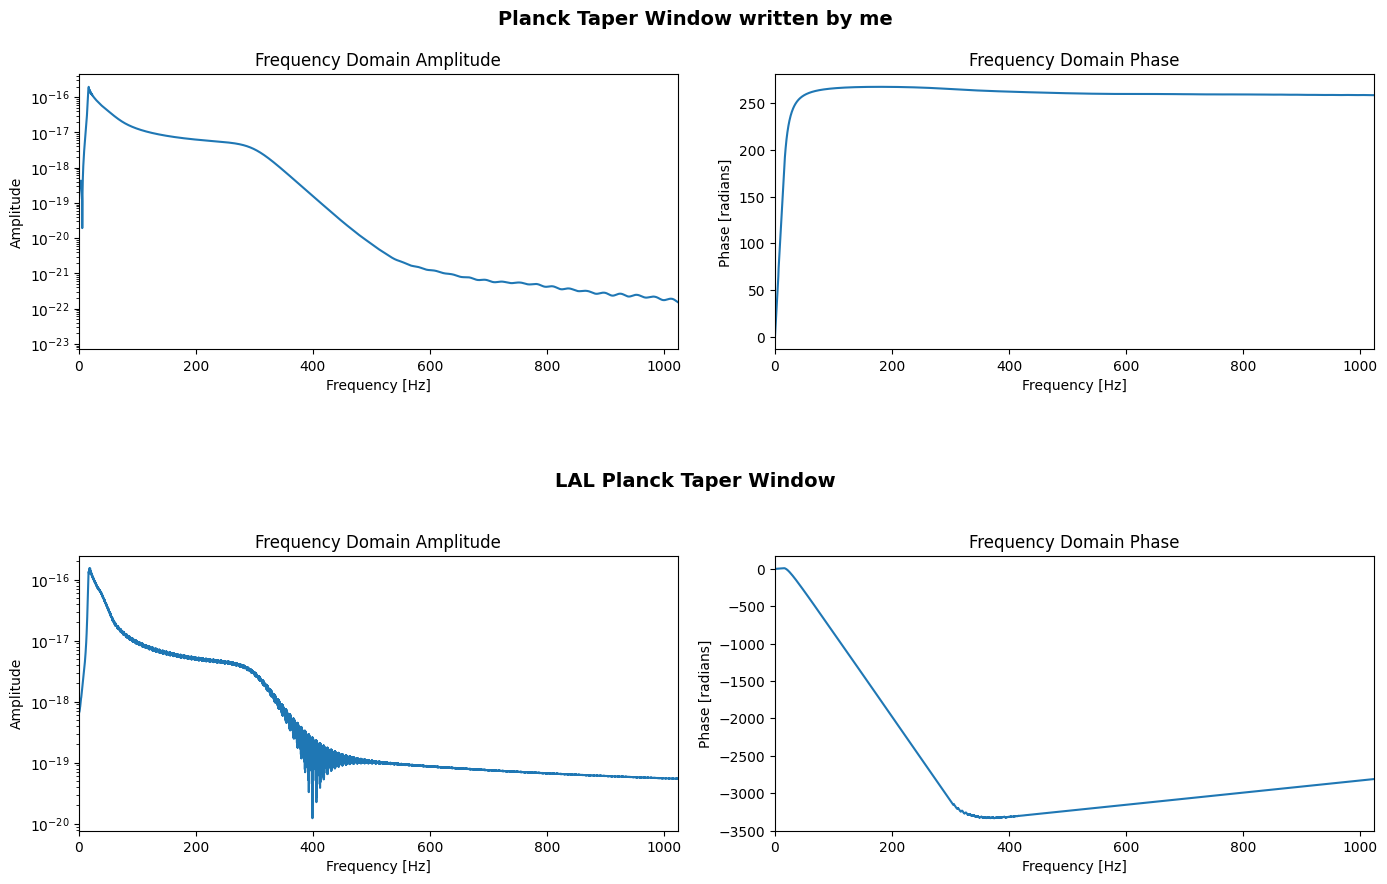

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(14, 6))
ax = axs.flatten()

fig.text(0.5, 0.95, "Planck Taper Window written by me", ha="center", va="center", fontsize=14, fontweight="bold")
fig.text(0.5, 0.18, "LAL Planck Taper Window", ha="center", va="center", fontsize=14, fontweight="bold")

ax[0].plot(hp_fd_freq_1, hp_fd_amp_1)
ax[0].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("Frequency Domain Amplitude")
ax[0].set_yscale("log")
ax[0].set_xlim(0, 1024)
# ax[0].set_ylim(0, hp_fd_amp.max()*1.1)

ax[1].plot(hp_fd_freq_1, phase_anchored_1)
ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel("Phase [radians]")
ax[1].set_title("Frequency Domain Phase")
ax[1].set_yscale("linear")
ax[1].set_xlim(0, 1024)
# ax[1].set_ylim(-np.pi, np.pi)

ax[2].plot(hp_fd_freq_2, hp_fd_amp_2)
ax[2].set_xlabel("Frequency [Hz]")
ax[2].set_ylabel("Amplitude")
ax[2].set_title("Frequency Domain Amplitude")
ax[2].set_yscale("log")
ax[2].set_xlim(0, 1024)
# ax[2].set_ylim(0, hp_fd_amp.max()*1.1)

ax[3].plot(hp_fd_freq_2, phase_anchored_2)
ax[3].set_xlabel("Frequency [Hz]")
ax[3].set_ylabel("Phase [radians]")
ax[3].set_title("Frequency Domain Phase")
ax[3].set_yscale("linear")
ax[3].set_xlim(0, 1024)
# ax[3].set_ylim(-np.pi, np.pi)

plt.tight_layout(rect=[0, -0.5, 1, 0.92])
fig.subplots_adjust(hspace=0.75)
plt.show()